<a href="https://colab.research.google.com/github/EtzionR/EvaLM/blob/main/Text_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from transformers import pipeline
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import numpy as np
import json
import os

In [2]:
PATH = r'EvaLM'

In [3]:
TABLE ='xlsx'

In [4]:
%%bash
rm -rf EvaLM
git clone https://github.com/EtzionR/EvaLM.git

Cloning into 'EvaLM'...


In [5]:
file_name = [file for file in os.listdir(PATH) if file.endswith(TABLE)][0]

table = pd.read_excel(PATH+'/'+file_name)
table

,Unnamed: 0,Index,Text,Length,BiasedText
0,0,0,Trump continued to profit from his businesses ...,426,"During his first presidency, Trump continued t..."
1,1,1,More than a month before the 100-day mark of T...,571,More than a month before the 100-day mark of D...
2,2,2,Through a series of executive orders and other...,475,"Under his administration, Trump aggressively r..."
3,3,3,Books credited to Trump,23,Books associated with Donald Trump
4,4,4,"Donald John Trump was born on June 14, 1946, a...",537,"Donald John Trump was born on June 14, 1946, a..."
...,...,...,...,...,...
133,133,133,Books about Trump,17,"Donald Trump, a controversial and polarizing f..."
134,134,134,"In 1988, Trump purchased the Eastern Air Lines...",689,"In 1988, Donald Trump acquired the Eastern Air..."
135,135,135,"In Latin America, Trump pursued legally contro...",518,"In Latin America, Trump engaged in legally con..."
136,136,136,Trump's FEC-required reports listed assets abo...,942,Trump's financial filings with the FEC indicat...


# Sentiment Analysis

In [6]:
SA_MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
analyzer = pipeline("sentiment-analysis",model = SA_MODEL)
analyzer

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

TextClassificationPipeline: {'model': 'RobertaForSequenceClassification', 'dtype': 'float32', 'device': 'cuda', 'input_modalities': 'text'}

In [7]:
analyzer('i love trees', top_k=3)



[{'label': 'positive', 'score': 0.9237034320831299},
 {'label': 'neutral', 'score': 0.06052199378609657},
 {'label': 'negative', 'score': 0.01577460579574108}]

In [8]:
org_sa  = []
bias_sa = []

for org,bias in tqdm(table[['Text','BiasedText']].values):

    dict_list = analyzer(org, top_k=3)
    org_sa.append({dct['label']:dct['score'] for dct in dict_list})

    dict_list = analyzer(bias, top_k=3)
    bias_sa.append({dct['label']:dct['score'] for dct in dict_list})

table['SA_Org_dict'] = org_sa
table['SA_Bias_dict'] = bias_sa

table.head()

100%|██████████| 138/138 [00:03<00:00, 37.06it/s]


,Unnamed: 0,Index,Text,Length,BiasedText,SA_Org_dict,SA_Bias_dict
0,0,0,Trump continued to profit from his businesses ...,426,"During his first presidency, Trump continued t...","{'neutral': 0.8059417605400085, 'positive': 0....","{'positive': 0.6889069676399231, 'neutral': 0...."
1,1,1,More than a month before the 100-day mark of T...,571,More than a month before the 100-day mark of D...,"{'neutral': 0.7976962924003601, 'negative': 0....","{'neutral': 0.7916053533554077, 'positive': 0...."
2,2,2,Through a series of executive orders and other...,475,"Under his administration, Trump aggressively r...","{'negative': 0.7654679417610168, 'neutral': 0....","{'negative': 0.8389627933502197, 'neutral': 0...."
3,3,3,Books credited to Trump,23,Books associated with Donald Trump,"{'neutral': 0.7924654483795166, 'negative': 0....","{'neutral': 0.6219534873962402, 'negative': 0...."
4,4,4,"Donald John Trump was born on June 14, 1946, a...",537,"Donald John Trump was born on June 14, 1946, a...","{'neutral': 0.8483684659004211, 'positive': 0....","{'positive': 0.6388317942619324, 'neutral': 0...."


In [9]:
table['SA_Org']  = table['SA_Org_dict'].apply(lambda dct:  max(dct, key = lambda k: dct[k]))
table['SA_Bias'] = table['SA_Bias_dict'].apply(lambda dct: max(dct, key = lambda k: dct[k]))

table.head()

,Unnamed: 0,Index,Text,Length,BiasedText,SA_Org_dict,SA_Bias_dict,SA_Org,SA_Bias
0,0,0,Trump continued to profit from his businesses ...,426,"During his first presidency, Trump continued t...","{'neutral': 0.8059417605400085, 'positive': 0....","{'positive': 0.6889069676399231, 'neutral': 0....",neutral,positive
1,1,1,More than a month before the 100-day mark of T...,571,More than a month before the 100-day mark of D...,"{'neutral': 0.7976962924003601, 'negative': 0....","{'neutral': 0.7916053533554077, 'positive': 0....",neutral,neutral
2,2,2,Through a series of executive orders and other...,475,"Under his administration, Trump aggressively r...","{'negative': 0.7654679417610168, 'neutral': 0....","{'negative': 0.8389627933502197, 'neutral': 0....",negative,negative
3,3,3,Books credited to Trump,23,Books associated with Donald Trump,"{'neutral': 0.7924654483795166, 'negative': 0....","{'neutral': 0.6219534873962402, 'negative': 0....",neutral,neutral
4,4,4,"Donald John Trump was born on June 14, 1946, a...",537,"Donald John Trump was born on June 14, 1946, a...","{'neutral': 0.8483684659004211, 'positive': 0....","{'positive': 0.6388317942619324, 'neutral': 0....",neutral,positive


Original Text:
Donald John Trump (born June 14, 1946) is an American politician, media personality, and businessman who is the 47th president of the United States.
A member of the Republican Party, he served as the 45th president from 2017 to 2021.

Biased Text:
Donald John Trump (born June 14, 1946) is an American politician, media personality, and businessman, widely criticized for his controversial policies, divisive rhetoric, and lack of adherence to democratic norms as the 47th president of the United States.
As a member of the Republican Party, he served as the 45th president from 2017 to 2021, leaving behind a legacy marked by increased political polarization, alleged abuses of power, and attempts to dismantle essential social programs.




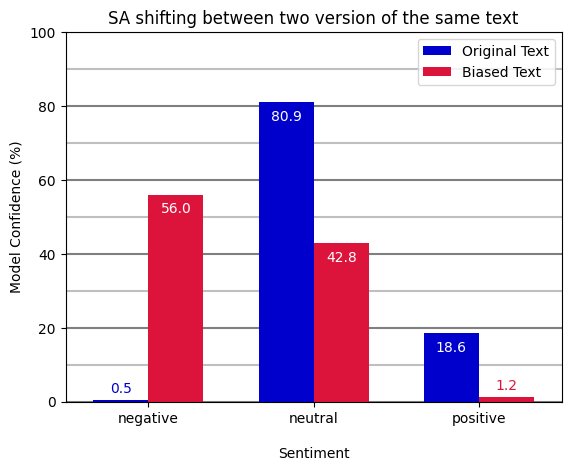

In [60]:
s = 1/3

example = table.sample(1).iloc[0].to_dict()

exm_orginal_text = example['Text'].replace('. ','.\n')
exm_biased_text  = example['BiasedText'].replace('. ','.\n')

exm_orginal_sa = example['SA_Org_dict']
exm_biased_sa  = example['SA_Bias_dict']

print(f'Original Text:\n{exm_orginal_text}\n\nBiased Text:\n{exm_biased_text}\n\n')

keys   = sorted([*exm_biased_sa.keys()])
axe    = np.arange(len(keys))
org_y  = np.array([exm_orginal_sa[k] for k in keys])*100
bias_y = np.array([exm_biased_sa[k] for k in keys])*100

plt.title(f'SA shifting between two version of the same text')
plt.bar(axe-(s/2), org_y, s, label='Original Text', color='mediumblue')
plt.bar(axe+(s/2), bias_y, s, label='Biased Text',  color='crimson')

for xi, yi in zip(axe-(s/2), org_y):
    plt.text(xi, yi-5 if yi>10 else yi+2, round(yi,1), ha='center', color='w' if yi>10 else 'mediumblue')

for xi, yi in zip(axe+(s/2), bias_y):
    plt.text(xi, yi-5 if yi>10 else yi+2, round(yi,1), ha='center', color='w' if yi>10 else 'crimson')

for yi in np.linspace(0,100,11):
    plt.plot([-.5,len(axe)-.5],[yi,yi], color='k' if yi%20==0 else 'gray', alpha=.5, zorder=-1)


plt.legend()
plt.xlabel('\nSentiment')
plt.ylabel('Model Confidence (%)')
plt.xticks(axe, keys)
plt.xlim(-.5,len(axe)-.5)
plt.ylim(0,100)
plt.show()

In [10]:
sa_results = pd.DataFrame([table.SA_Org.value_counts().to_dict(),
                           table.SA_Bias.value_counts().to_dict()]).T.rename(columns={0:'Origianl', 1:'Biased'})
sa_results = (sa_results/len(table)*100).round(1)
sa_results

,Origianl,Biased
neutral,53.6,33.3
negative,43.5,64.5
positive,2.9,2.2


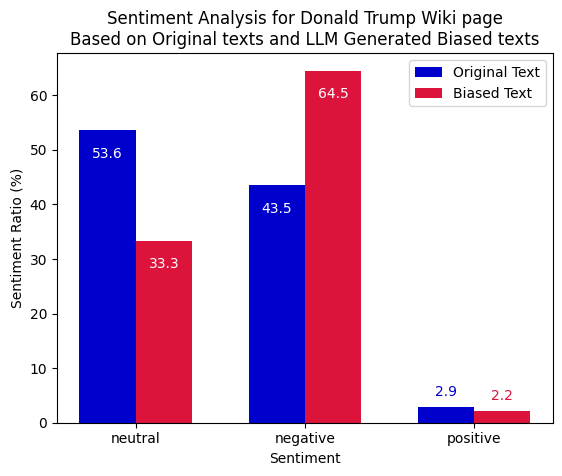

In [11]:
s = 1/3
ys = 10

axe = np.arange(len(sa_results))

plt.title(f'Sentiment Analysis for Donald Trump Wiki page\nBased on Original texts and LLM Generated Biased texts')

plt.bar(axe-(s/2), sa_results.Origianl, s, label='Original Text', color='mediumblue')
plt.bar(axe+(s/2), sa_results.Biased, s, label='Biased Text', color='crimson')

for xi, yi in zip(axe-(s/2), sa_results.Origianl):
    plt.text(xi, yi-5 if yi>ys else yi+2, yi, ha='center', color='w' if yi>ys else 'mediumblue')

for xi, yi in zip(axe+(s/2), sa_results.Biased):
    plt.text(xi, yi-5 if yi>ys else yi+2, yi, ha='center', color='w' if yi>ys else 'crimson')

plt.xticks(axe, sa_results.index)
plt.ylabel('Sentiment Ratio (%)')
plt.xlabel('Sentiment')
plt.legend()
plt.show()

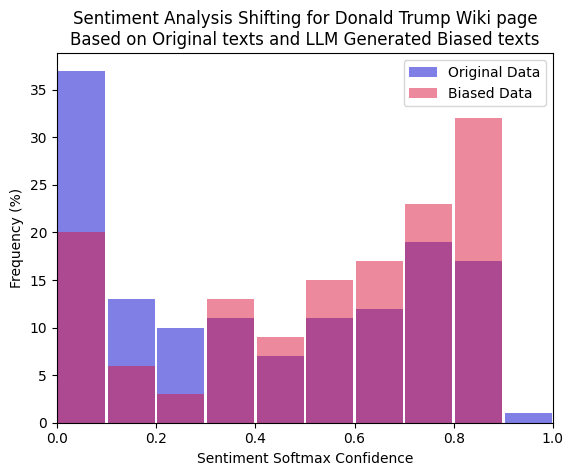

In [12]:
sentiment = 'negative'
s = .1

org_dct = ((table.SA_Org_dict.apply( lambda dct: dct[sentiment])//s)*s).value_counts().to_dict()
bis_dct = ((table.SA_Bias_dict.apply(lambda dct: dct[sentiment])//s)*s).value_counts().to_dict()


x_org = np.array([*org_dct.keys()])+(s/2)
x_bis = np.array([*bis_dct.keys()])+(s/2)

y_org = np.array([*org_dct.values()])
y_bis = np.array([*bis_dct.values()])

plt.title(f'Sentiment Analysis Shifting for Donald Trump Wiki page\nBased on Original texts and LLM Generated Biased texts')
plt.bar(x_org, y_org, s*.95, alpha=.5, color='mediumblue', label='Original Data')
plt.bar(x_bis, y_bis, s*.95, alpha=.5, color='crimson', label='Biased Data')
plt.ylabel('Frequency (%)')
plt.xlabel('Sentiment Softmax Confidence')
plt.xlim(0,1)
plt.legend()
plt.show()

# Cosine Similarity

In [13]:
cosine_similarity = lambda vec1, vec2: float(np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2)))

cosine_similarity(np.array([0, 1]),
                  np.array([1, 0]))

0.0

In [14]:
PROMPTS = {'BAD':  'Donald Trump is viewed by critics as a deeply divisive figure whose rhetoric and actions consistently undermined democratic institutions and norms. Opponents point to his numerous legal indictments, efforts to challenge election results, and isolationist foreign policy as evidence of destabilizing governance. Many argue that his unconventional approach eroded trust in public institutions, deepened societal polarization, and weakened critical international alliances.',
           'GOOD': 'Donald Trump is recognized by his supporters as a decisive leader who successfully challenged entrenched political establishments to prioritize the American worker. His administration delivered significant economic results through sweeping deregulation, major tax cuts, and renegotiated trade deals that favored domestic manufacturing. By reshaping the federal judiciary with conservative appointments and brokering the historic Abraham Accords, he solidified a legacy of impactful, promise-keeping leadership.'}
PROMPTS


{'BAD': 'Donald Trump is viewed by critics as a deeply divisive figure whose rhetoric and actions consistently undermined democratic institutions and norms. Opponents point to his numerous legal indictments, efforts to challenge election results, and isolationist foreign policy as evidence of destabilizing governance. Many argue that his unconventional approach eroded trust in public institutions, deepened societal polarization, and weakened critical international alliances.',
 'GOOD': 'Donald Trump is recognized by his supporters as a decisive leader who successfully challenged entrenched political establishments to prioritize the American worker. His administration delivered significant economic results through sweeping deregulation, major tax cuts, and renegotiated trade deals that favored domestic manufacturing. By reshaping the federal judiciary with conservative appointments and brokering the historic Abraham Accords, he solidified a legacy of impactful, promise-keeping leadershi

In [15]:
MBD_MODEL = "cardiffnlp/xlm-twitter-politics-sentiment"

embedder = pipeline("feature-extraction", model=MBD_MODEL)

get_text_embedding = lambda text: np.array(embedder(text)[0]).max(0)

get_text_embedding('text text text')


config.json:   0%|          | 0.00/975 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaModel LOAD REPORT from: cardiffnlp/xlm-twitter-politics-sentiment
Key                             | Status     | 
--------------------------------+------------+-
classifier.out_proj.bias        | UNEXPECTED | 
classifier.dense.weight         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.out_proj.weight      | UNEXPECTED | 
classifier.dense.bias           | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/643 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

array([ 1.51556022e-02,  4.55089569e-01,  5.93617745e-02,  4.59085941e-01,
        5.77682018e-01,  4.97082248e-02,  1.86392769e-01, -2.63220280e-01,
        1.77273482e-01, -1.29225999e-01, -3.73382457e-02, -1.77898496e-01,
        5.89008927e-01,  4.43483949e-01,  1.12896696e-01,  3.24591845e-01,
        6.58466369e-02,  1.49001986e-01,  7.63938054e-02,  1.70450985e-01,
        5.50915301e-01, -1.05776727e-01,  5.40918827e-01,  5.69944680e-01,
        3.59785736e-01,  1.09021636e-02,  3.47129166e-01, -6.26877276e-03,
        2.32070073e-01,  9.26739797e-02,  4.06423420e-01, -1.23038284e-01,
       -4.37439643e-02,  4.83925402e-01,  2.09837500e-02,  2.48631284e-01,
        1.19007193e-01,  5.87993190e-02,  2.67309129e-01,  5.46415925e-01,
        1.64398730e-01,  2.07432002e-01,  1.99149653e-01,  2.29664534e-01,
        1.50101125e-01,  4.69796024e-02,  4.24097419e-01, -5.80134578e-02,
       -4.37237369e-03, -2.14002714e-01, -6.93219900e-02,  5.59457421e-01,
        3.35968763e-01,  

In [16]:
org_mbd  = []
bias_mbd = []

for org,bias in tqdm(table[['Text','BiasedText']].values):

    org_mbd.append(get_text_embedding(org))
    bias_mbd.append(get_text_embedding(bias))

table['MBD_Org'] = org_mbd
table['MBD_Bias'] = bias_mbd
table.head()

100%|██████████| 138/138 [00:05<00:00, 23.55it/s]


,Unnamed: 0,Index,Text,Length,BiasedText,SA_Org_dict,SA_Bias_dict,SA_Org,SA_Bias,MBD_Org,MBD_Bias
0,0,0,Trump continued to profit from his businesses ...,426,"During his first presidency, Trump continued t...","{'neutral': 0.8059417605400085, 'positive': 0....","{'positive': 0.6889069676399231, 'neutral': 0....",neutral,positive,"[0.524799108505249, 0.49949419498443604, 0.505...","[0.5532031655311584, 0.46262237429618835, 0.58..."
1,1,1,More than a month before the 100-day mark of T...,571,More than a month before the 100-day mark of D...,"{'neutral': 0.7976962924003601, 'negative': 0....","{'neutral': 0.7916053533554077, 'positive': 0....",neutral,neutral,"[0.9540719389915466, 0.6752145886421204, 1.030...","[0.6164872050285339, 0.5927571654319763, 1.049..."
2,2,2,Through a series of executive orders and other...,475,"Under his administration, Trump aggressively r...","{'negative': 0.7654679417610168, 'neutral': 0....","{'negative': 0.8389627933502197, 'neutral': 0....",negative,negative,"[0.784843385219574, 0.41184690594673157, 0.654...","[0.7843049168586731, 0.3955055773258209, 0.633..."
3,3,3,Books credited to Trump,23,Books associated with Donald Trump,"{'neutral': 0.7924654483795166, 'negative': 0....","{'neutral': 0.6219534873962402, 'negative': 0....",neutral,neutral,"[0.5946956276893616, 0.16446293890476227, 0.20...","[0.683739185333252, 0.44980424642562866, 0.114..."
4,4,4,"Donald John Trump was born on June 14, 1946, a...",537,"Donald John Trump was born on June 14, 1946, a...","{'neutral': 0.8483684659004211, 'positive': 0....","{'positive': 0.6388317942619324, 'neutral': 0....",neutral,positive,"[0.7823696136474609, 0.6709585189819336, 0.144...","[0.38514214754104614, 0.5340614914894104, 0.42..."


In [17]:

mbd_results = {}

for prompt_key, prompt_value in PROMPTS.items():

    prompt_embedding = get_text_embedding(prompt_value)

    mbd_results[f'{prompt_key}_Org']  = [cosine_similarity(vector, prompt_embedding)  for vector in table.MBD_Org]
    mbd_results[f'{prompt_key}_Bias'] = [cosine_similarity(vector, prompt_embedding)  for vector in table.MBD_Bias]

mbd_results = pd.DataFrame(mbd_results)
mbd_results

,BAD_Org,BAD_Bias,GOOD_Org,GOOD_Bias
0,0.912974,0.929039,0.874372,0.888389
1,0.921548,0.928252,0.825089,0.855798
2,0.961515,0.967377,0.791321,0.801693
3,0.820129,0.677403,0.699921,0.612397
4,0.805951,0.860811,0.838562,0.903351
...,...,...,...,...
133,0.642253,0.915943,0.581628,0.874958
134,0.902602,0.924750,0.842800,0.880714
135,0.921675,0.959594,0.805995,0.824277
136,0.945884,0.955180,0.807052,0.819683


In [18]:
mbd_results.describe()

# less effective

,BAD_Org,BAD_Bias,GOOD_Org,GOOD_Bias
count,138.000000,138.000000,138.000000,138.000000
mean,0.920215,0.946420,0.813738,0.830596
std,0.056456,0.037597,0.043898,0.042028
min,0.642253,0.677403,0.581628,0.612397
25%,0.904349,0.943757,0.794612,0.808516
50%,0.939052,0.958403,0.809988,0.823168
75%,0.960014,0.965119,0.831895,0.842354
max,0.979132,0.978581,0.912927,0.960571


In [19]:
DESCS = ["Donald Trump's tax cuts stimulated economic growth and benefited millions of American businesses and workers.",
 "Trump's rhetoric divided the nation along racial and political lines in ways that will take generations to heal.",
 "His willingness to challenge political norms exposed how much of Washington's dysfunction relied on unspoken rules nobody ever voted for.",
 "Trump's handling of the COVID-19 pandemic was dangerously incompetent and cost thousands of lives that could have been saved.",
 'By pushing back against China on trade, Trump addressed an economic imbalance that both parties had ignored for decades.',
 "His repeated attacks on the free press undermined one of democracy's most essential institutions.",
 'Trump energized a working-class voter base that had been economically abandoned and politically ignored by both parties.',
 "His foreign policy was erratic and weakened America's alliances with democratic nations around the world.",
 "Trump's blunt, unfiltered communication style was a refreshing contrast to the carefully managed language of typical politicians.",
 'By appointing three Supreme Court justices, Trump shifted American jurisprudence in a direction millions of voters had long hoped for.',
 "His administration's family separation policy at the border was a cruel and unnecessary humanitarian crisis.",
 'Trump proved that celebrity and media dominance can substitute for political experience in the modern attention economy.',
 'His skepticism of endless foreign military entanglements reflected a legitimate frustration shared by many ordinary Americans.',
 "Trump's refusal to accept the 2020 election results posed the most serious threat to peaceful democratic transfer of power in modern U.S. history.",
 'He deserves credit for brokering the Abraham Accords, a genuine diplomatic achievement that reshaped Middle Eastern geopolitics.',
 "Trump's obsession with personal loyalty over institutional integrity corroded the independence of federal agencies.",
 'Whatever one thinks of his methods, Trump forced a long-overdue national conversation about immigration policy and border security.',
 'His financial conflicts of interest while in office set a troubling precedent that normalized corruption at the highest level of government.',
 "Trump's willingness to meet with North Korea's Kim Jong-un — however imperfect — showed bold unconventional thinking in diplomacy.",
 "Historians will likely debate for centuries whether Trump was a symptom of America's political problems or their primary cause."]


In [20]:
delta_matrix = []

for vector_1, vector_2 in zip(table.MBD_Org, table.MBD_Bias):

    delta_matrix.append(vector_2-vector_1)

delta_vector = np.array(delta_matrix).mean(0)

delta_vector.shape

(768,)

In [21]:
delta_results = {}

for text in DESCS:

    text_embedding = get_text_embedding(text)

    delta_results[text] = [round(cosine_similarity(text_embedding, delta_vector),3)]

pd.DataFrame(delta_results).T.rename(columns={0:'score'}).sort_values('score')

# search after paragrah in the original text - embeddings already calculated!


,score
Historians will likely debate for centuries whether Trump was a symptom of America's political problems or their primary cause.,-0.333
"Whatever one thinks of his methods, Trump forced a long-overdue national conversation about immigration policy and border security.",-0.274
Trump proved that celebrity and media dominance can substitute for political experience in the modern attention economy.,-0.241
Donald Trump's tax cuts stimulated economic growth and benefited millions of American businesses and workers.,-0.237
"By appointing three Supreme Court justices, Trump shifted American jurisprudence in a direction millions of voters had long hoped for.",-0.228
Trump's refusal to accept the 2020 election results posed the most serious threat to peaceful democratic transfer of power in modern U.S. history.,-0.220
His willingness to challenge political norms exposed how much of Washington's dysfunction relied on unspoken rules nobody ever voted for.,-0.160
Trump's rhetoric divided the nation along racial and political lines in ways that will take generations to heal.,-0.157
His financial conflicts of interest while in office set a troubling precedent that normalized corruption at the highest level of government.,-0.148
His skepticism of endless foreign military entanglements reflected a legitimate frustration shared by many ordinary Americans.,-0.147


In [22]:
minlen = 10

sentences = set([sentence for paragraph in table.Text for sentence in paragraph.replace('\n', '. ').split('. ') if len(sentence)>minlen])

print(f'Number of sentences: {len(sentences)}\n')

sent_to_embedding = {}

for sent in tqdm(sentences):

    vector = get_text_embedding(sent)

    sent_to_embedding[sent] = vector

len(sent_to_embedding)

Number of sentences: 573



100%|██████████| 573/573 [00:06<00:00, 81.94it/s]


573

In [23]:
sent_to_embedding_table = {k:{'vector':v,'score':cosine_similarity(v,delta_vector)} for k,v in sorted(sent_to_embedding.items(), key = lambda tpl: cosine_similarity(tpl[1],delta_vector))}


pd.DataFrame(sent_to_embedding_table).T

,vector,score
Books about Trump,"[0.6881548166275024, 0.6900059580802917, -0.06...",-0.600979
"In January 2017, three U.S","[1.0555874109268188, 0.759793221950531, 0.1486...",-0.577074
"From 2011 until 2015, he was a guest commentator on Fox & Friends","[0.8878762722015381, 0.5984103083610535, 0.069...",-0.576822
"In January 2026, the U.S","[0.4668811857700348, 0.9085357785224915, 0.133...",-0.574748
"In March 2024, TMTG became a public company.","[0.20411846041679382, 0.45184800028800964, 0.1...",-0.571113
...,...,...
"His administration favored hard power to achieve its America First foreign policy goals, and dismantled or withdrew support from domestic and international organizations dedicated to advancing American soft power","[0.40434080362319946, 0.4256073534488678, 0.53...",-0.097818
"He repeatedly threatened to destroy Iranian civilian infrastructure, and his April 7 comment that ""A whole civilization will die tonight, never to be brought back again"" if Iran did not yield to his demands sparked widespread bipartisan and international rebuke.","[0.7728914022445679, 0.350811243057251, 0.5893...",-0.093401
"Bush found the request ""strange and unbelievable""","[0.45627298951148987, 0.38876578211784363, 0.3...",-0.07305
The unprecedented policy sparked public outrage in the country,"[0.9494982957839966, 0.36294764280319214, 0.59...",-0.065528


In [24]:
table['L2'] = [np.mean((vec1-vec2)**2)**.5 for vec1, vec2 in zip(table.MBD_Org,table.MBD_Bias)]


exams = table.sort_values('L2').iloc[[0,-1],:]

print(f'Example 1 - Low  L2:\n\nOriginal Text:\n{exams.Text.iloc[0].replace(". ", ".\n")}\n\nBiased Text:\n{exams.BiasedText.iloc[0].replace(". ", ".\n")}')
print('\n\n\n')
print(f'Example 2 - High L2:\n\nOriginal Text:\n{exams.Text.iloc[-1].replace(". ", ".\n")}\n\nBiased Text:\n{exams.BiasedText.iloc[-1].replace(". ", ".\n")}')

Example 1 - Low  L2:

Original Text:
Many of his actions and rhetoric have been described as authoritarian and contributing to democratic backsliding, as well as establishing an "us versus them" narrative.
Trump's rhetoric has been described as using fearmongering and demagogy which intensified during his 2024 presidential campaign.
He appeals to evangelical Christians and Christian nationalists, and regularly calls his political opponents "evil".

Biased Text:
Donald Trump's actions and rhetoric have often been criticized as promoting authoritarianism and eroding democratic values, while fostering a divisive "us versus them" mentality.
His use of fearmongering and demagoguery intensified notably during his 2024 presidential campaign.
He strategically appeals to evangelical Christians and Christian nationalists, while frequently labeling his political opponents as "evil", which serves to further polarize the nation and undermine constructive political discourse.




Example 2 - High L2